# ラーメン二郎価格の可視化

データは `jirou_prices_tidy_long.csv` を使用します。

作成する図は次の 3 種類です。

1. 絶対価格ヒートマップ
2. 「小」のランキング棒グラフ
3. 総合スコア棒グラフ

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import os, io, urllib.request

# --- 日本語フォント設定 ---
candidate_fonts = [
    "Hiragino Sans",       # macOS
    "Hiragino Maru Gothic Pro",
    "Yu Gothic",           # Windows
    "Noto Sans CJK JP",   # Linux / Colab
    "IPAexGothic",
]

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = None
for font_name in candidate_fonts:
    if font_name in available_fonts:
        selected_font = font_name
        break

# Colab環境で日本語フォントが無い場合はインストール
if selected_font is None:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "japanize-matplotlib", "-q"])
        import japanize_matplotlib
        print("日本語フォント: japanize-matplotlib")
    except Exception:
        print("日本語フォントを自動検出できませんでした。")
else:
    plt.rcParams["font.family"] = selected_font
    print("日本語フォント:", selected_font)

# --- データ読み込み（ローカル / Colab 両対応） ---
GITHUB_DATA = 'https://raw.githubusercontent.com/ryo-nakajima/undergrad-io-2026-data/main/data'
LOCAL_PATH = Path("jirou_prices_tidy_long.csv")

if LOCAL_PATH.exists():
    DATA_PATH = LOCAL_PATH
elif Path("data/jirou_prices_tidy_long.csv").exists():
    DATA_PATH = Path("data/jirou_prices_tidy_long.csv")
else:
    DATA_PATH = None  # GitHubから読む

OUTPUT_DIR = Path("figures_jirou")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INCLUDE_BEER = False
ANNOTATE_HEATMAP = True

print("DATA_PATH =", DATA_PATH if DATA_PATH else "GitHub raw URL")
print("OUTPUT_DIR =", OUTPUT_DIR)

In [ ]:
if DATA_PATH:
    df = pd.read_csv(DATA_PATH)
else:
    url = f'{GITHUB_DATA}/jirou_prices_tidy_long.csv'
    response = urllib.request.urlopen(url)
    df = pd.read_csv(io.StringIO(response.read().decode('utf-8')))

display(df.head())
print(df.columns.tolist())
print(df.shape)

In [12]:
required_cols = ["店名", "メニュー", "価格円"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"必要な列が不足しています: {missing_cols}")

plot_df = df.copy()
plot_df = plot_df[plot_df["価格円"].notna()].copy()

if not INCLUDE_BEER:
    plot_df = plot_df[plot_df["メニュー"] != "ビール"].copy()

menu_order = ["小", "小豚", "小W", "大", "大豚", "大W", "つけ", "ビール"]
existing_menu_order = [m for m in menu_order if m in plot_df["メニュー"].unique()]

wide = plot_df.pivot_table(
    index="店名",
    columns="メニュー",
    values="価格円",
    aggfunc="first"
)

wide = wide.reindex(columns=existing_menu_order)

print("対象店舗数:", wide.shape[0])
print("対象メニュー:", list(wide.columns))
display(wide.head())


対象店舗数: 45
対象メニュー: ['小', '小豚', '小W', '大', '大豚', '大W', 'つけ']


メニュー,小,小豚,小W,大,大豚,大W,つけ
店名,,,,,,,
ひたちなか店,900.0,1100.0,NaN,1000.0,1200.0,NaN,NaN
ひばりヶ丘駅前店,1000.0,1120.0,NaN,1100.0,1300.0,NaN,NaN
めじろ台店,900.0,1050.0,NaN,1000.0,1150.0,NaN,NaN
一橋学園店,900.0,1100.0,NaN,950.0,1150.0,NaN,NaN
三田本店,700.0,850.0,950.0,750.0,900.0,1000.0,NaN


In [13]:
def _copied_cmap(name: str):
    cmap = mpl.colormaps[name]
    try:
        cmap = cmap.copy()
    except AttributeError:
        pass
    return cmap

def plot_heatmap(
    data_df,
    title,
    save_path,
    cmap_name="viridis",
    center=None,
    fmt="int",
    annotate=True,
    figsize_width=11,
    row_height=0.34,
):
    plot_values = data_df.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(plot_values)

    fig_height = max(8, data_df.shape[0] * row_height)
    fig, ax = plt.subplots(figsize=(figsize_width, fig_height))

    cmap = _copied_cmap(cmap_name)
    try:
        cmap.set_bad(color="lightgray")
    except Exception:
        pass

    kwargs = {"aspect": "auto", "interpolation": "none", "cmap": cmap}

    if center is not None:
        vmax = np.nanmax(np.abs(plot_values))
        kwargs["vmin"] = -vmax
        kwargs["vmax"] = vmax

    im = ax.imshow(masked, **kwargs)

    cbar = plt.colorbar(im, ax=ax)
    if center is None:
        cbar.set_label("価格（円）")
    else:
        cbar.set_label("メニュー別中央値との差（円）")

    ax.set_xticks(range(data_df.shape[1]))
    ax.set_xticklabels(data_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(data_df.shape[0]))
    ax.set_yticklabels(data_df.index)
    ax.set_title(title)

    if annotate:
        for i in range(data_df.shape[0]):
            for j in range(data_df.shape[1]):
                val = plot_values[i, j]
                if np.isnan(val):
                    continue

                if fmt == "int":
                    text = f"{int(round(val))}"
                elif fmt == "signed":
                    text = f"{val:+.0f}"
                else:
                    text = f"{val:.1f}"

                ax.text(j, i, text, ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"saved: {save_path}")

def plot_barh(series, title, xlabel, save_path, figsize_width=9, row_height=0.32):
    fig_height = max(6, len(series) * row_height)
    fig, ax = plt.subplots(figsize=(figsize_width, fig_height))
    ax.barh(series.index, series.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"saved: {save_path}")


## 1. 絶対価格ヒートマップ

店舗ごとの平均価格で並べ替えて、全体として高い店が上に来るようにしています。


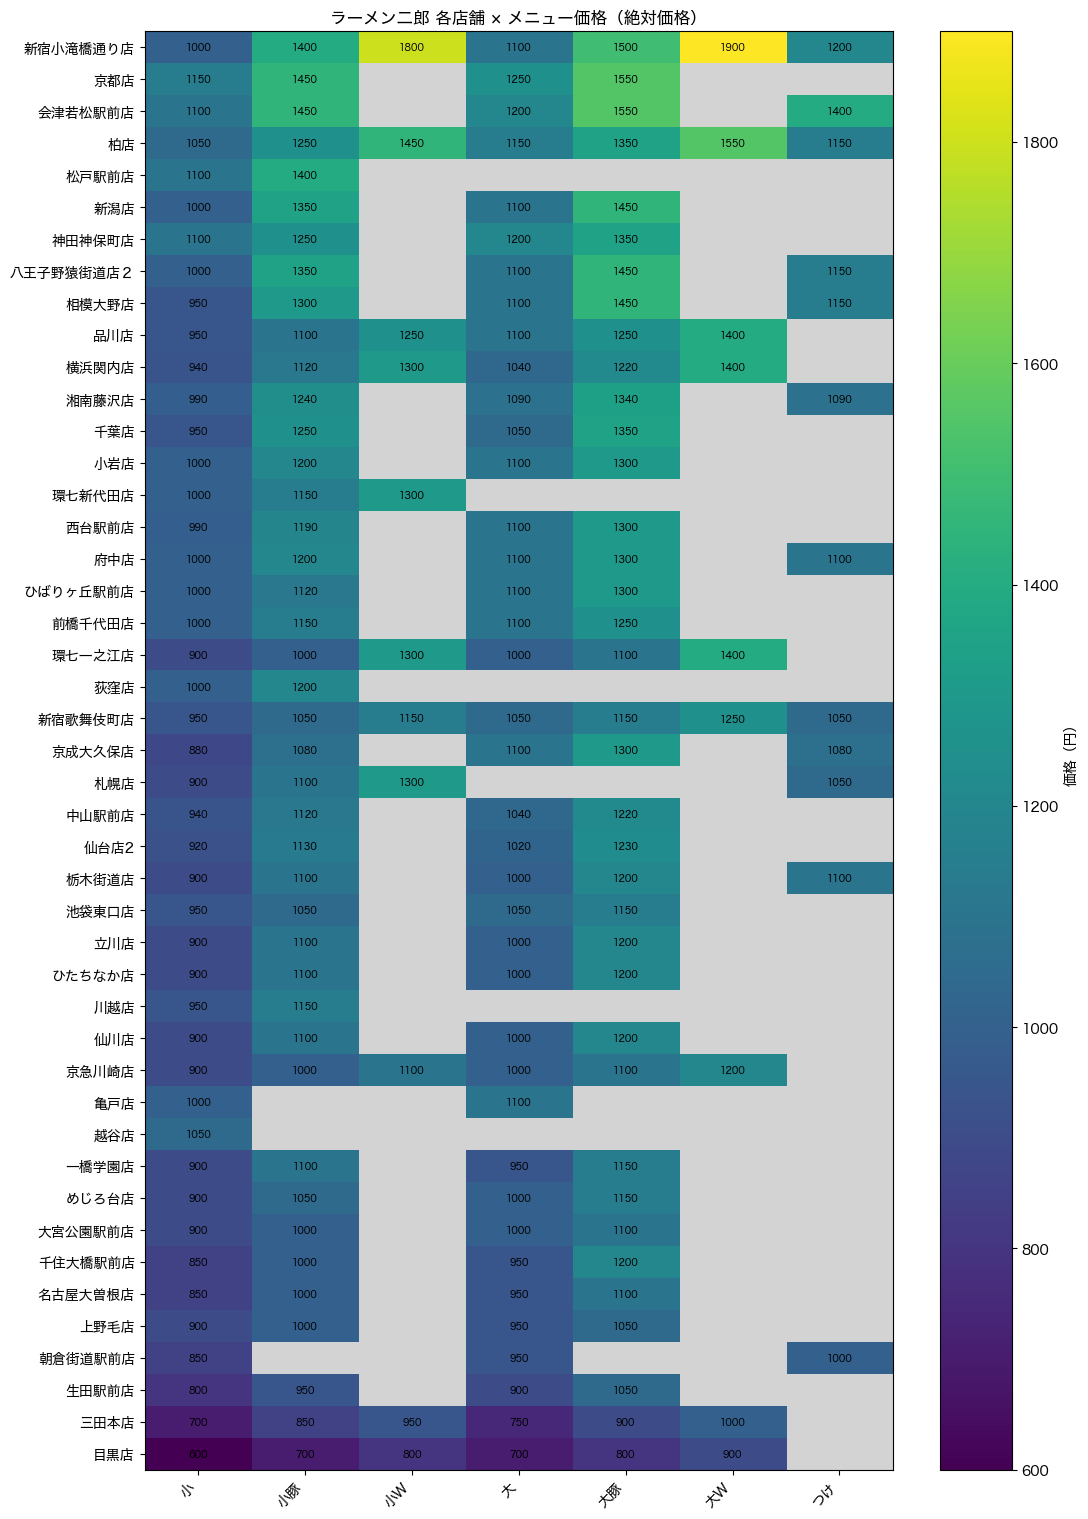

saved: /Users/ryo2/Dropbox/UnderGradIO/UndergradIO2026/code/figures_jirou/01_absolute_price_heatmap.png


In [14]:
absolute_heatmap = wide.copy()
absolute_heatmap["平均価格"] = absolute_heatmap.mean(axis=1, skipna=True)
absolute_heatmap = absolute_heatmap.sort_values("平均価格", ascending=False)
absolute_heatmap = absolute_heatmap.drop(columns="平均価格")

plot_heatmap(
    data_df=absolute_heatmap,
    title="ラーメン二郎 各店舗 × メニュー価格（絶対価格）",
    save_path=OUTPUT_DIR / "01_absolute_price_heatmap.png",
    cmap_name="viridis",
    center=None,
    fmt="int",
    annotate=ANNOTATE_HEATMAP,
)


## 2. 「小」のランキング棒グラフ

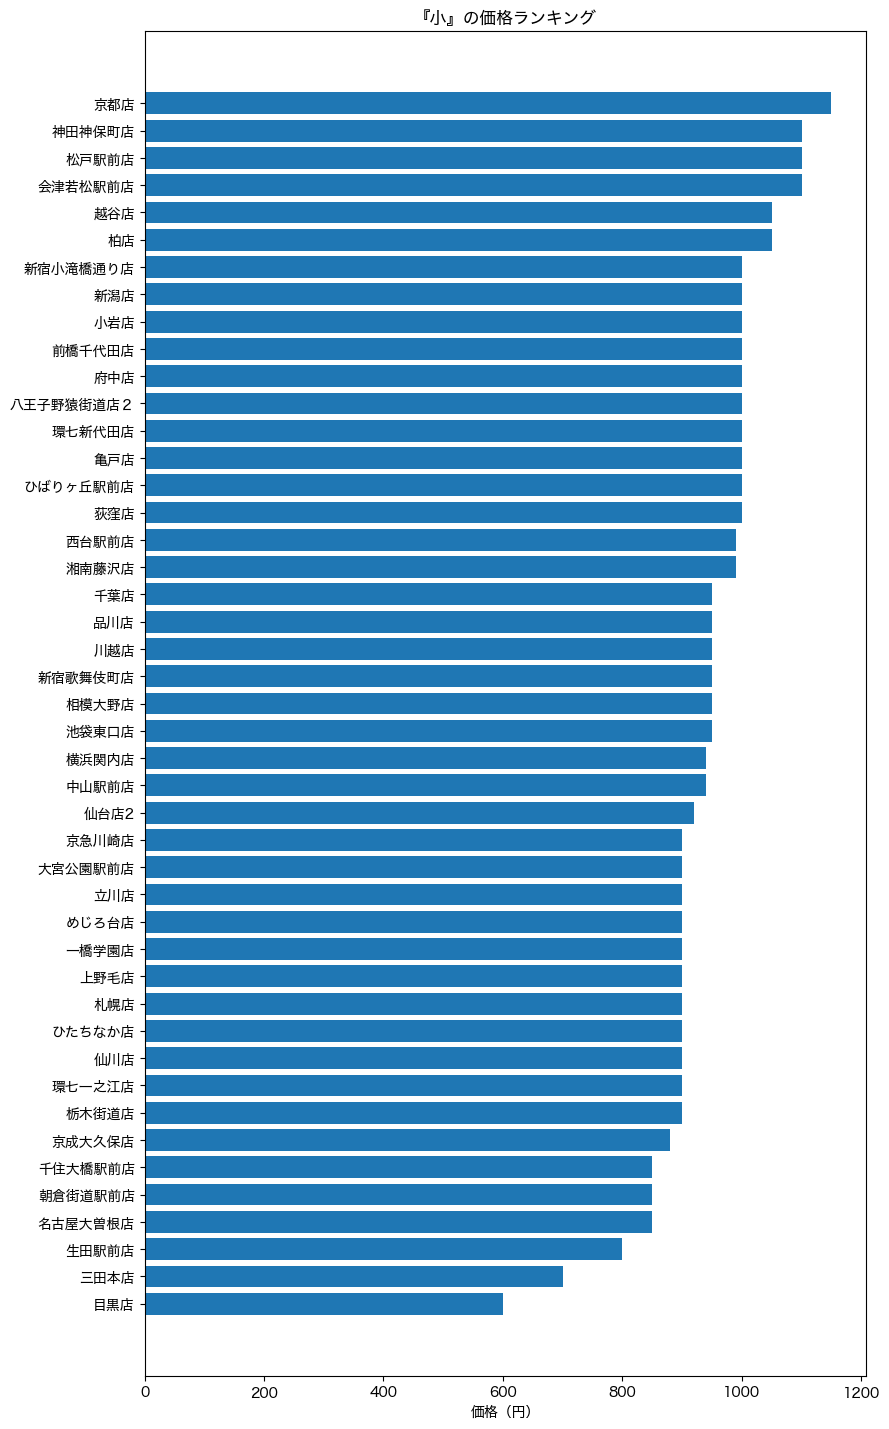

saved: /Users/ryo2/Dropbox/UnderGradIO/UndergradIO2026/code/figures_jirou/02_small_price_ranking.png


In [15]:
if "小" not in wide.columns:
    raise ValueError("メニュー『小』が見つかりません。")

small_rank = wide["小"].dropna().sort_values()

plot_barh(
    series=small_rank,
    title="『小』の価格ランキング",
    xlabel="価格（円）",
    save_path=OUTPUT_DIR / "02_small_price_ranking.png",
)


## 3. 総合スコア棒グラフ

各店舗について、各メニューの中央値との差を計算し、その平均を総合スコアとしています。  
正の値が大きいほど全体として高め、負の値が大きいほど全体として安めです。


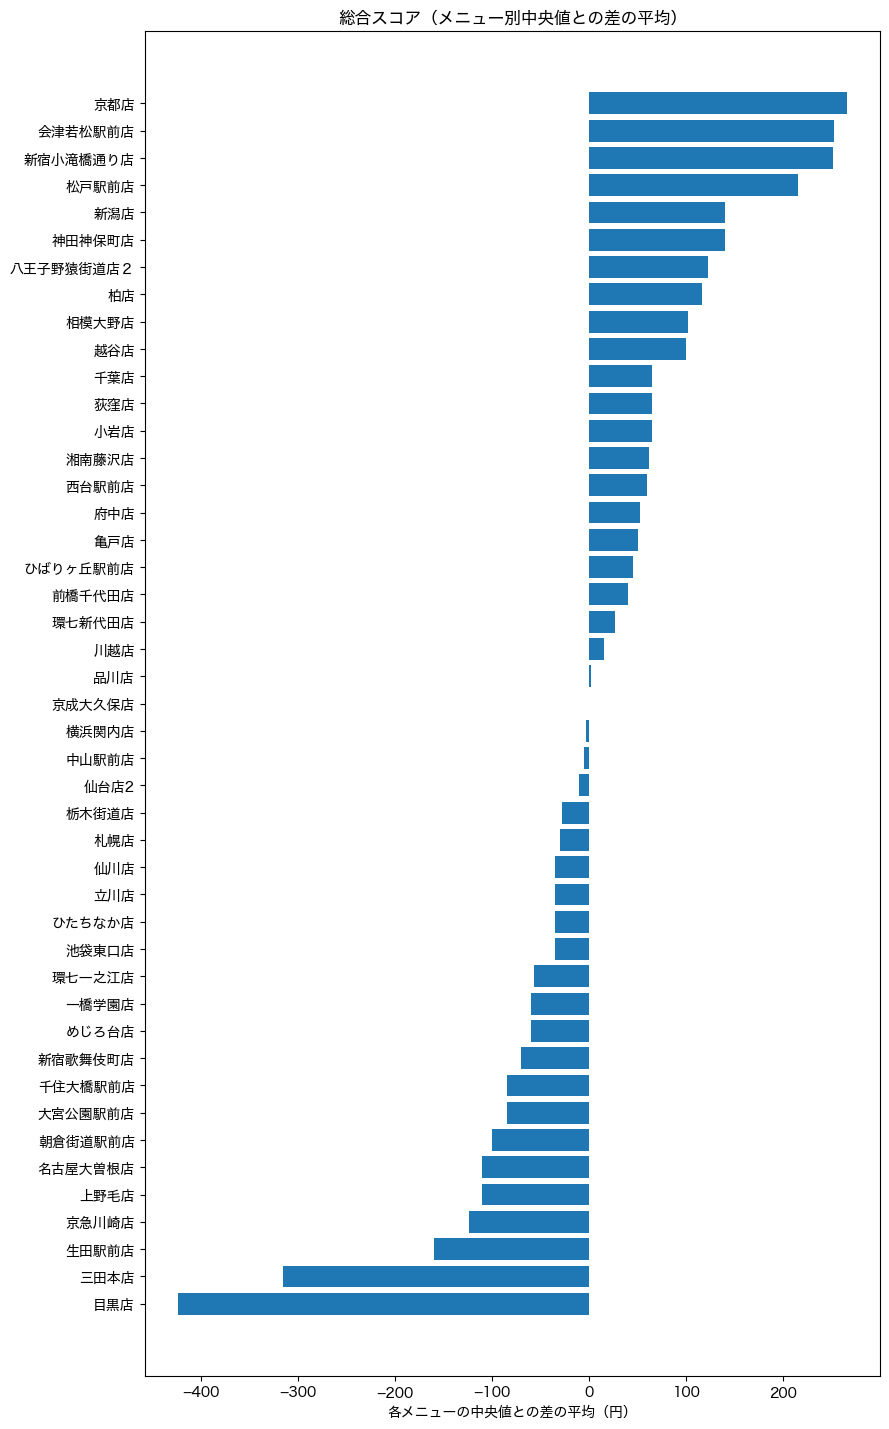

saved: /Users/ryo2/Dropbox/UnderGradIO/UndergradIO2026/code/figures_jirou/03_overall_score_barh.png


In [16]:
menu_medians = wide.median(axis=0, skipna=True)
deviation = wide.sub(menu_medians, axis=1)
overall_score = deviation.mean(axis=1, skipna=True).sort_values()

plot_barh(
    series=overall_score,
    title="総合スコア（メニュー別中央値との差の平均）",
    xlabel="各メニューの中央値との差の平均（円）",
    save_path=OUTPUT_DIR / "03_overall_score_barh.png",
)


## 参考: 上位・下位の確認

In [17]:
summary_table = pd.DataFrame({
    "小の価格": wide["小"],
    "総合スコア": overall_score.reindex(wide.index)
})

print("小の価格が安い順 上位10店")
display(summary_table.sort_values("小の価格").head(10))

print("小の価格が高い順 上位10店")
display(summary_table.sort_values("小の価格", ascending=False).head(10))

print("総合スコアが低い店 上位10店")
display(summary_table.sort_values("総合スコア").head(10))

print("総合スコアが高い店 上位10店")
display(summary_table.sort_values("総合スコア", ascending=False).head(10))


小の価格が安い順 上位10店


,小の価格,総合スコア
店名,,
目黒店,600.0,-423.333333
三田本店,700.0,-315.000000
生田駅前店,800.0,-160.000000
名古屋大曽根店,850.0,-110.000000
朝倉街道駅前店,850.0,-100.000000
千住大橋駅前店,850.0,-85.000000
京成大久保店,880.0,0.000000
栃木街道店,900.0,-28.000000
環七一之江店,900.0,-56.666667


小の価格が高い順 上位10店


,小の価格,総合スコア
店名,,
京都店,1150.0,265.000000
会津若松駅前店,1100.0,252.000000
松戸駅前店,1100.0,215.000000
神田神保町店,1100.0,140.000000
柏店,1050.0,115.714286
越谷店,1050.0,100.000000
環七新代田店,1000.0,26.666667
亀戸店,1000.0,50.000000
小岩店,1000.0,65.000000


総合スコアが低い店 上位10店


,小の価格,総合スコア
店名,,
目黒店,600.0,-423.333333
三田本店,700.0,-315.000000
生田駅前店,800.0,-160.000000
京急川崎店,900.0,-123.333333
上野毛店,900.0,-110.000000
名古屋大曽根店,850.0,-110.000000
朝倉街道駅前店,850.0,-100.000000
大宮公園駅前店,900.0,-85.000000
千住大橋駅前店,850.0,-85.000000


総合スコアが高い店 上位10店


,小の価格,総合スコア
店名,,
京都店,1150.0,265.000000
会津若松駅前店,1100.0,252.000000
新宿小滝橋通り店,1000.0,251.428571
松戸駅前店,1100.0,215.000000
神田神保町店,1100.0,140.000000
新潟店,1000.0,140.000000
八王子野猿街道店２,1000.0,122.000000
柏店,1050.0,115.714286
相模大野店,950.0,102.000000
